# Federated learning: ECI 2026 Project

This is the [final optional project](http://ichatz.me/Site/FederatedLearningECI2026Project) for the course Federated Learning taught by [Ioannis Chatzigiannakis](http://ichatz.me/Site/Home) at the Escuelas de Ciencias Informáticas in July 2026. 

The course itself followed the idea of dataset descentralization to perform Machine Learning to avoid providing sensitive (raw) data to privately-owned servers, during the course we also tackled the problems regarding non-IIDness, adversarial clients, privacy & security. 

It was overall a fantastic course that really sparked my interest in what is usually an underlooked aspect of digitalization, how we protect our data & the trust we place in big corporations.

With that being said, the objective here is to simulate a small federated learning scenario using CIFAR-10 dataset, compare aggregation strategies and use a centralized baseline to showcase the tradeoff that comes from not exposing private data.



### Index
----
* [SETUP](#setup)
* [Dataset](#dataset)
    * [Analysis](#analysis)
* [Model](#model)
    * [Train & Test steps](#train--test-steps)
    * [Model Training](#model-training)
* [Centralized Baseline](#centralized-baseline)
    * [Metrics](#metrics)
        * [Accuracy & Loss Trends](#accuracy--loss-trends)
        * [Confusion Matrix](#confusion-matrix)
* [Federated Scenario](#federated-scenario)
    * [Simulating Non-IID-ness](#simulating-non-iid-ness)
        * [FedArtML label-skew protocol](#fedartml-label-skew-protocol)
        * [Client dataset generation](#client-dataset-generation)
    * [Quantifying Non-IIDness](#quantifying-non-iidness)
        * [1. Hellinger Distance](#1-hellinger-distance)
        * [2. Earth Mover's Distance (EMD)](#2-earth-movers-distance-emd)
        * [3. Jensen-Shannon divergence (JSD)](#3-jensen-shannon-divergence-jsd)
        * [4. Population Stability Index](#4-population-stability-index)
        * [5. Bubble Chart](#5-bubble-chart)
        * [6. Total Quantity](#6-total-quantity)
        * [Takeaway](#takeaway)
    * [Local Models training](#local-models-training)
        * [Adam-Optimized Models](#adam-optimized-models)
        * [SGD-Optimized Models](#sgd-optimized-models)
    * [Federated Learning Aggregation Strategies](#federated-learning-aggregation-strategies)
----

### SETUP

First we need to install Tensorflow, the dataset & MatPlotLib 

In [1]:
!pip install -q matplotlib
!pip install -q tensorflow tensorflow_probability[tf]
!pip install -q numpy
!pip3 install -q torch torchvision --index-url https://download.pytorch.org/whl/cpu
!pip install -q scikit-learn

Then we import it

In [2]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import torchvision
import tensorflow_probability as tfp
import numpy as np
import torch.nn as nn
import torch
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
import copy
import math

---
## Dataset

I'm going to be using [CIFAR10](https://www.tensorflow.org/datasets/catalog/cifar10?hl=es), a dataset containing 60000 32x32 colour images uniformly distributed amongst 10 classes. 

We want an equal label-wise distribution using a **60/10/30** split for training, validation & test, for that reason we must stratify the split using the labels 

> The dataset itself is pre-split so we need to recombine it and then split it

In [3]:
cifar10_classes = [
    "airplane",   
    "automobile", 
    "bird",       
    "cat",        
    "deer",       
    "dog",        
    "frog",       
    "horse",      
    "ship",       
    "truck"       
]

In [4]:
train_data = torchvision.datasets.CIFAR10(root="data", train=True, download=True)
test_data = torchvision.datasets.CIFAR10(root="data", train=False, download=True)

train_labels = torch.from_numpy(np.array(train_data.targets)).long()
test_labels = torch.from_numpy(np.array(test_data.targets)).long()

train_images = torch.from_numpy(train_data.data)
test_images = torch.from_numpy(test_data.data)

train_images_normalized = (train_images).float() / 255.0   
train_images_normalized = train_images_normalized.permute(0, 3, 1, 2)                 # (N, H, W, C) -> (N, C, H, W)

test_images_normalized = (test_images).float() / 255.0   
test_images_normalized = test_images_normalized.permute(0, 3, 1, 2)                 # (N, H, W, C) -> (N, C, H, W)

train_labels = (train_labels).long()   
test_labels = (test_labels).long()     

images = torch.cat([train_images_normalized, test_images_normalized], dim=0)
labels = torch.cat([train_labels, test_labels], dim=0)

# First we take the 60% split
X_train, X_temp, Y_train, y_temp = train_test_split(
    images, labels,
    test_size=0.40,      
    random_state=42,
    stratify=labels   
)

# Then we split the remaining 40% of the dataset into 10/30
X_val, X_test, Y_val, Y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.75,      
    random_state=42,
    stratify=y_temp      
)

train_data = TensorDataset(X_train, Y_train)
val_data   = TensorDataset(X_val, Y_val)
test_data  = TensorDataset(X_test, Y_test)

print(train_data.tensors[0].shape)  
print(train_data.tensors[1].shape)


torch.Size([36000, 3, 32, 32])
torch.Size([36000])


### Analysis

Now we can plot and visualize some of the data distribution, in particular we can see

1.  Histogram of the classes
2.  Few samples

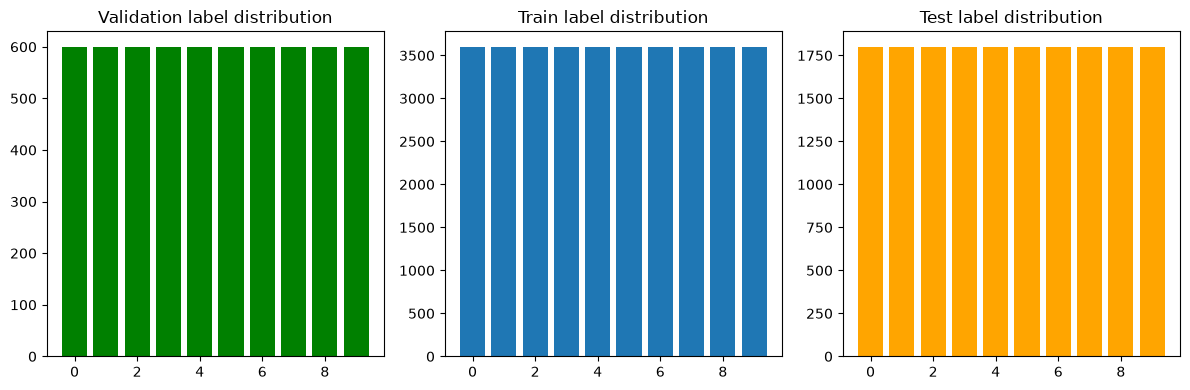

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].bar(np.unique_counts(Y_val).values, np.unique_counts(Y_val).counts, color="green")
axes[0].set_title("Validation label distribution")
axes[1].bar(np.unique_counts(Y_train).values, np.unique_counts(Y_train).counts)
axes[1].set_title("Train label distribution")
axes[2].bar(np.unique_counts(Y_test).values, np.unique_counts(Y_test).counts, color="orange")
axes[2].set_title("Test label distribution")

plt.tight_layout()
plt.show()

As we can see there is no quantity skewness because all labels have exactly 6000 samples (although we will split it into non-IID scenarios).

Let's visualize some samples of the images to get a general idea of what they look like

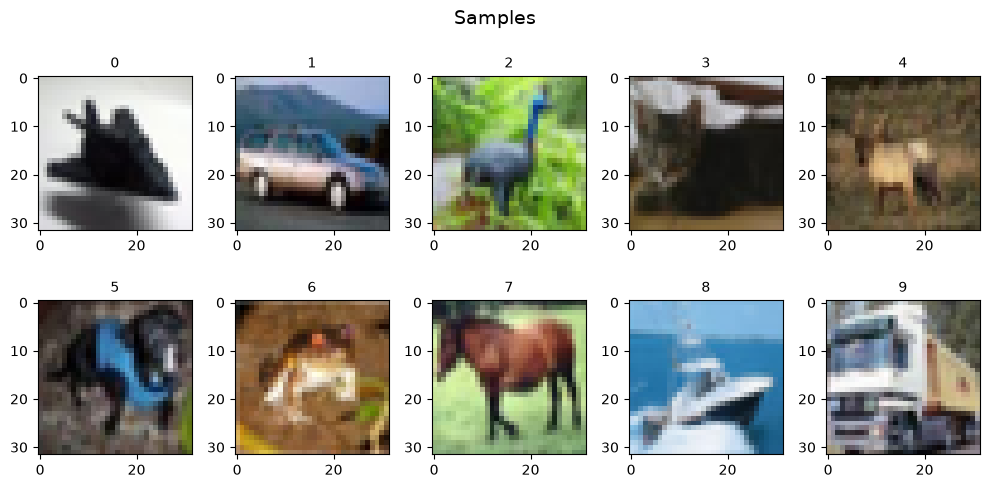

In [6]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

axes_flat = axes.flatten()

for i in range(10):
    j = 0
    while train_labels[j] != i:
        j += 1
        
    if j < len(train_labels):
        ax = axes_flat[i]
        ax.imshow(train_images[j])
        ax.set_title(f"{train_labels[j]}", fontsize=10)

plt.suptitle("Samples", fontsize=14)
plt.tight_layout()
plt.show()

---
## Model 

We will define our model's layers looking at the dataset's shape

In [7]:
print(train_data.tensors[0].shape) #X shape
print(train_data.tensors[1].shape) #Y shape

torch.Size([36000, 3, 32, 32])
torch.Size([36000])


### Architecture

We will use a 2D Sequential Convolutional Neural Network for this task, note that the same model will be utilized across all scenarios (centralized & local), this is to have a common middle-ground but this might not always be the most favorable case.

<details>
<summary><b>Sources</b></summary>

* Model:    
    -   [Sequential CNNs](https://docs.pytorch.org/docs/2.13/generated/torch.nn.Sequential.html)
* Layers: 
    -   [Conv2D](https://docs.pytorch.org/docs/2.13/generated/torch.nn.Conv2d.html#torch.nn.Conv2d)
    -   [AveragePooling2D](https://docs.pytorch.org/docs/2.13/generated/torch.nn.AvgPool2d.html#torch.nn.AvgPool2d)
    -   [Flatten](https://docs.pytorch.org/docs/2.13/generated/torch.nn.Flatten.html#torch.nn.Flatten)
    -   [Linear (Dense)](https://docs.pytorch.org/docs/2.13/generated/torch.nn.Linear.html#torch.nn.Linear)
    -   [Dropout](https://docs.pytorch.org/docs/2.13/generated/torch.nn.Dropout.html#torch.nn.Dropout)
*   Activation Functions:
    -   [softmax](https://docs.pytorch.org/docs/2.13/generated/torch.nn.Softmax.html)
    -   [relu](https://docs.pytorch.org/docs/2.13/generated/torch.nn.ReLU.html)

</details>


In [8]:
initial_model = nn.Sequential(

    #Feature Extraction
    nn.Conv2d(3, 8, (7,7), padding="same", stride=1), #3 channels (image has color, otherwise it'd be 1 channel?)
    nn.ReLU(),
    nn.AvgPool2d(kernel_size=(2,2)),
    nn.Conv2d(8, 16, (5,5), padding="same", stride=1),
    nn.ReLU(),
    nn.AvgPool2d(kernel_size=(2,2)),
    nn.Conv2d(16, 32, (3,3), padding="same", stride=1),
    nn.ReLU(),

    #Classifier
    nn.Flatten(), 
    nn.Dropout(p=0.3),
    nn.Linear(2048, 128), #value 2048 is because of 32x32x32x3 / 2 / 2 
    nn.Dropout(p=0.3),
    nn.Linear(128, 64),
    nn.Linear(64,10),
    nn.LogSoftmax(dim=1)
)

### Train & Test steps

Now with our model properly defined we have to define what training and testing means

Training will take each (image,label) tuple and make the model predict the label, after that we calculate the loss with the truth and then perform backpropagation.

Testing will also take (image, label) tuples, predict a label, validate the result and finally calculate the overall guess rate 

In [9]:


def train(model, optimizer, dataLoader, loss_fn):
    model.train()
    total_loss = 0
    dataset_size = len(dataLoader.dataset)
    for (X, y) in (dataLoader):

        # Predict then calculate loss
        pred = model(X)

        loss = loss_fn(pred, y)

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        #Calculate loss 
        total_loss += loss.item() * X.size(0)

    avg_loss = total_loss/dataset_size

    return model, avg_loss

def test(model, dataLoader, loss_fn):
    model.eval()
    total_loss = 0
    correct = 0
    dataset_size = len(dataLoader.dataset)

    #.no_grad makes the model not learn from the passes 
    with torch.no_grad():
        for X, y in dataLoader:
            #Predict & if it's right add it to the guess count
            pred = model(X)
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()

            #Calculate loss 
            loss = loss_fn(pred, y)
            total_loss += loss.item() * X.size(0)

    avg_loss = total_loss / dataset_size
    accuracy = correct / dataset_size

    return (accuracy, avg_loss)



### Model Training 

With all pieces in place we can now define an optimized training routine that will track accuracy over the validation set and restore the best weights if no improvements are seen after 3 epochs, we will utilize 2 optimizers and compare the results 

In [10]:
def run_model(model, optimizer, epochs, train_dataloader, val_dataloader):

    best_model = copy.deepcopy(model)
    best_model_accuracy = 0
    stall_count = 0
    train_accAndloss_arr = []
    val_accAndloss_arr = []

    for t in range(epochs):
        model, current_loss = train(model, optimizer, train_dataloader, nn.NLLLoss())  #We train the model
        (model_accuracy, current_loss) = test(model, val_dataloader, nn.NLLLoss())    #Get it's validation accuracy

        val_accAndloss_arr.append((model_accuracy,current_loss))    
        train_accAndloss_arr.append(test(model, train_dataloader, nn.NLLLoss()))        #Calculate accuracy on train dataset (for over/underfitting)

        if(model_accuracy < best_model_accuracy):
            stall_count += 1    
        else:
            best_model = copy.deepcopy(model)                            
            best_model_accuracy = model_accuracy
            stall_count = 0

        if(stall_count == 3):
            model.load_state_dict(best_model.state_dict())
            return train_accAndloss_arr, val_accAndloss_arr

    model.load_state_dict(best_model.state_dict())
    return train_accAndloss_arr, val_accAndloss_arr


---
## Centralized Baseline

As we attempt to showcase the effectiveness of Federated Learning (& the challenges it poses) we need a baseline to compare it to, in this case the obvious thing to do is to have a standard centralized model using the entire dataset, as if all clients sent their data.

Training the centralized model is fairly straightforward now, first we construct the dataloaders using the centralized dataset and then we run both models

In [11]:
train_dataloader = DataLoader(train_data, batch_size=32, shuffle=True)
val_dataloader = DataLoader(val_data, batch_size=32, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=32, shuffle=True)

The Adam model

In [12]:
Adam_model = copy.deepcopy(initial_model)
Adam_optimizer = torch.optim.Adam(Adam_model.parameters())
Adam_train_metrics, Adam_val_metrics = run_model(Adam_model, Adam_optimizer, epochs=100, train_dataloader=train_dataloader, val_dataloader=val_dataloader)

Then the SGD model

In [13]:
SGD_model = copy.deepcopy(initial_model)
SGD_optimizer = torch.optim.SGD(SGD_model.parameters(), momentum=0.9)
SGD_train_metrics, SGD_val_metrics = run_model(SGD_model, SGD_optimizer, epochs=100, train_dataloader=train_dataloader, val_dataloader=val_dataloader)

### Metrics

#### Accuracy & Loss Trends

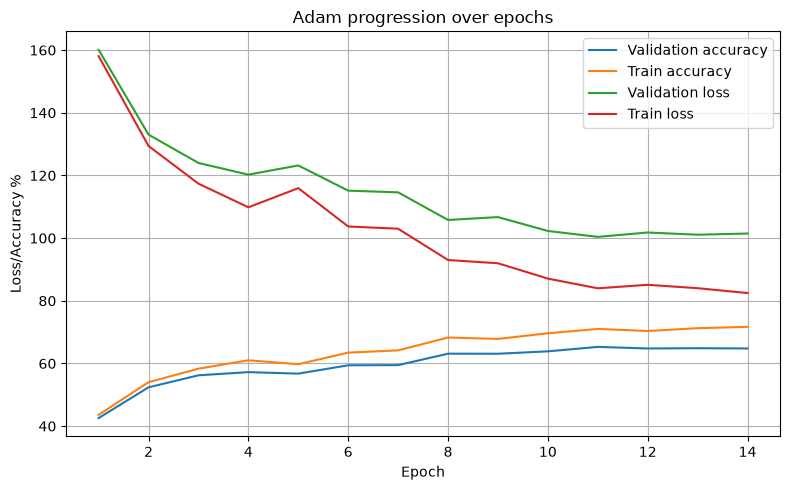

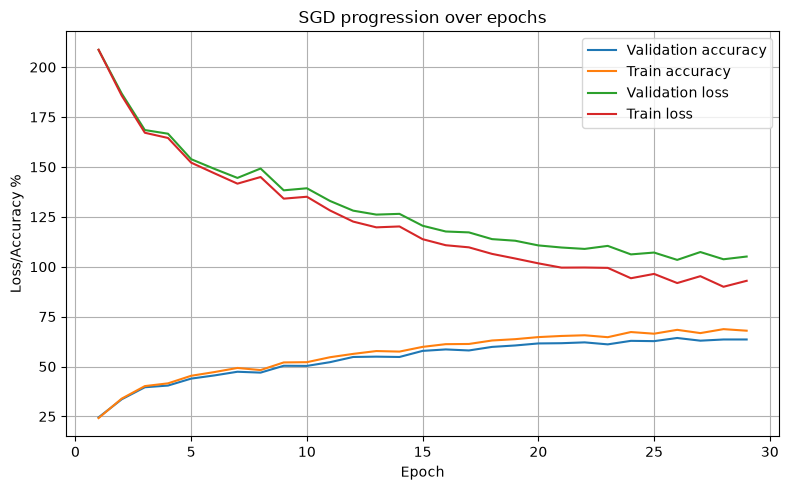

In [14]:
import matplotlib.pyplot as plt


Adam_val_acc = [acc * 100 for (acc, _) in Adam_val_metrics]
Adam_val_loss = [loss * 100 for (_, loss) in Adam_val_metrics]
Adam_train_acc = [acc * 100 for (acc, _) in Adam_train_metrics]
Adam_train_loss = [loss * 100 for (_, loss) in Adam_train_metrics]


SGD_val_acc = [acc * 100 for (acc, _) in SGD_val_metrics]
SGD_val_loss = [loss * 100 for (_, loss) in SGD_val_metrics]
SGD_train_acc = [acc * 100 for (acc, _) in SGD_train_metrics]
SGD_train_loss = [loss * 100 for (_, loss) in SGD_train_metrics]

adam_epoch_range = range(1, len(Adam_val_metrics)+1)
sgd_epoch_range = range(1, len(SGD_val_metrics)+1)


# Adam Loss
plt.figure(figsize=(8, 5))
plt.plot(adam_epoch_range, Adam_val_acc, label='Validation accuracy')
plt.plot(adam_epoch_range, Adam_train_acc, label='Train accuracy')
plt.plot(adam_epoch_range, Adam_val_loss, label='Validation loss')
plt.plot(adam_epoch_range, Adam_train_loss, label='Train loss')
plt.xlabel('Epoch')
plt.ylabel('Loss/Accuracy %')
plt.title('Adam progression over epochs')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# SGD Loss
plt.figure(figsize=(8, 5))
plt.plot(sgd_epoch_range, SGD_val_acc, label='Validation accuracy')
plt.plot(sgd_epoch_range, SGD_train_acc, label='Train accuracy')
plt.plot(sgd_epoch_range, SGD_val_loss, label='Validation loss')
plt.plot(sgd_epoch_range, SGD_train_loss, label='Train loss')
plt.xlabel('Epoch')
plt.ylabel('Loss/Accuracy %')
plt.title('SGD progression over epochs')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

#### Confusion Matrix

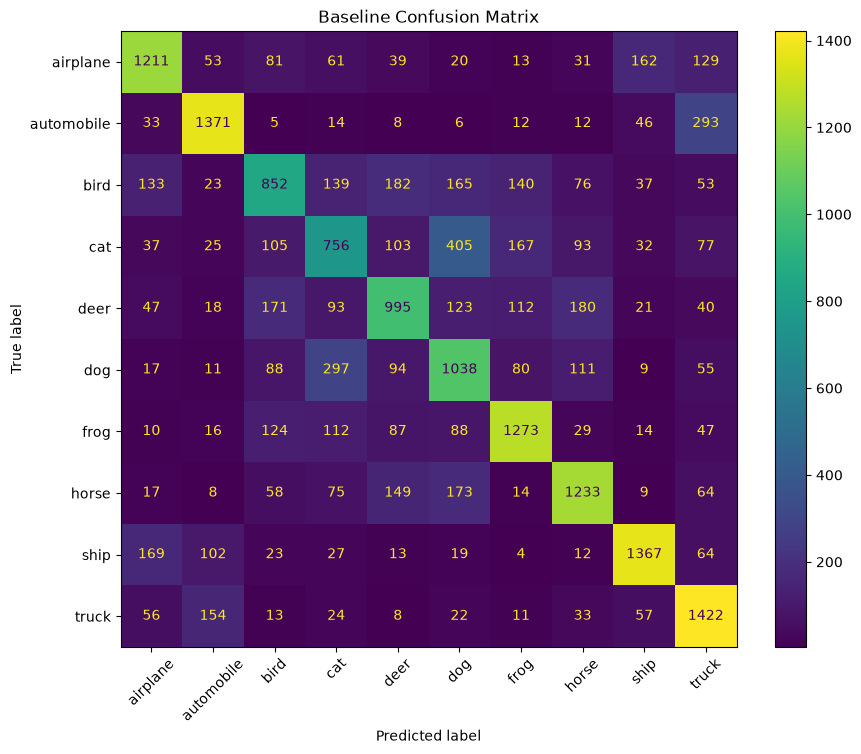

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_cm(model, dataLoader, title,ax):
    model.eval()
    predictions = []
    y_test = []
    #.no_grad makes the model not learn from the passes 
    with torch.no_grad():
        for X, y in dataLoader:
            #Predict & if it's right add it to the guess count
            pred = model(X)
            pred_labels =  pred.argmax(dim=1)
            predictions.extend(pred_labels.cpu().numpy())
            y_test.extend(y.cpu().numpy())

    cm = confusion_matrix(y_test, predictions)
    disp = ConfusionMatrixDisplay(cm, display_labels=cifar10_classes)
    disp.plot(xticks_rotation=45, ax=ax)
    disp.ax_.set_title(title)
    return disp

fig, ax = plt.subplots(figsize=(10, 8))

plot_cm(model=Adam_model, dataLoader=test_dataloader, title="Baseline Confusion Matrix", ax=ax)
plt.show()


As expected our baseline model is fairly good at predicting all classes, with some slight symmetrical confussion between cats & dogs and asymmetrical confussion by mixing up deers with birds. Even so, most are insignificant as we can see a strong diagonal. 

---
## Clients Datasets

Now we reach the point were we can start creating the federated environment, splitting the dataset and training the local models to simulate a federated context.

### Simulating Non-IID-ness

Real clients will never achieve IID-ness over the dataset, meaning that some sort label-skewness is always present and in order to achieve that we'll perform a Dirichlet-based label-skew partition. 

#### FedArtML label-skew protocol


This entails setting up a distribution vector for each of the 10 classes present in our dataset, for our case study we will simulate $K=10$ clients and analyze 4 different concentrations 

$\alpha = 1000,1,0.5, 0.1$

In [16]:
K = 10

tfd = tfp.distributions

alphas = {
    1000: [1000.0]*10,
    1: [1]*10,
    0.5: [0.5]*10,
    0.1: [0.1]*10
}

alphas_class_distributions = {}

for key, value in alphas.items():
    dist = tfd.Dirichlet(alphas[key])
    alphas_class_distributions[key] = dist.sample([10])

#### Client dataset generation

For each alpha we now have a matrix containing label-skew representations for each of the classes (that is, the distribution percentage of samples for each of the classes amongst all clients). 

We can now split the centralized dataset into "local" versions for each client 

In [17]:
def fractions_to_counts(fracs, n):  #Our Dirichlet split will represents the percentage of each class the clients will take, so we calculate the actual sample amount
    raw = [float(f) * n for f in fracs]
    counts = [int(x) for x in raw]  
    remainder = n - sum(counts)

    fractional_parts = sorted(
        range(len(raw)), key=lambda i: raw[i] - int(raw[i]), reverse=True
    )
    for i in fractional_parts[:remainder]:
        counts[i] += 1

    assert sum(counts) == n
    return counts

In [18]:
SPLITS = {"train": train_data, "test": test_data, "val": val_data}

def split_by_class(dataset):
    labels = dataset.tensors[1]
    class_datasets = [None] * 10
    for c in range(10):
        idx = torch.where(labels == c)[0]
        class_datasets[c] = torch.utils.data.Subset(dataset, idx)
    return class_datasets

classes_by_split = {name: split_by_class(ds) for name, ds in SPLITS.items()}

def build_client_datasets(class_distributions, K):
    clients_datasets = {i: {name: [] for name in SPLITS} for i in range(K)}
    client_class_counts = {i: [0] * 10 for i in range(K)}

    for class_index in range(10):
        fracs = class_distributions[class_index].numpy().tolist()
        for split_name, class_subsets in classes_by_split.items():
            subset = class_subsets[class_index]
            counts = fractions_to_counts(fracs, len(subset))
            client_subsets = torch.utils.data.random_split(subset, counts)
            for i in range(K):
                clients_datasets[i][split_name].append(client_subsets[i])
                if split_name == "train":
                    client_class_counts[i][class_index] = counts[i]

    for i in range(K):
        for split_name in SPLITS:
            clients_datasets[i][split_name] = torch.utils.data.ConcatDataset(clients_datasets[i][split_name])

    return clients_datasets, client_class_counts

alpha_clients_datasets = {}
alpha_client_class_counts = {}

for alpha, class_distributions in alphas_class_distributions.items():
    alpha_clients_datasets[alpha], alpha_client_class_counts[alpha] = build_client_datasets(class_distributions, K)

### Quantifying Non-IIDness 

We can now quantify how Non-IDD our federated datasets are by using a couple of different metrics, we will first setup a few useful variables

In [19]:
def normalize(counts):
    total = sum(counts)
    return [c / total for c in counts] if total else [0.0] * len(counts)


baseline = [0.1] * 10

client_class_distribution = {}

client_class_distribution = {
    alpha: {i: normalize(alpha_client_class_counts[alpha][i]) for i in range(K)}
    for alpha in alphas_class_distributions
}

In most cases we will like to compare the federated set to an ideal scenario where all data has been equally distributed.

> An ideal IID scenario would have a distribution of $\frac{1}{C}$ for all items, where $C$ is the number of classes.


Now for the metrics

#### 1. Hellinger Distance

$$ H(P,Q) = \frac{1}{\sqrt{2}}\sqrt{\sum^{n}_{i=1}{\Bigl(\sqrt{P(i)}-\sqrt{Q(i)}\Bigr)^2}}$$

With it's value ranging from 0 to 1, where 0 means absolute IID and 1 means completely disjoint P,Q sets.

In [20]:
def HellingerDistance(P,Q):

    sum = 0

    for i in range(len(P)):
        sum += (P[i]**0.5 - Q[i]**0.5)**2

    return 1/(2**0.5) * sum**0.5 

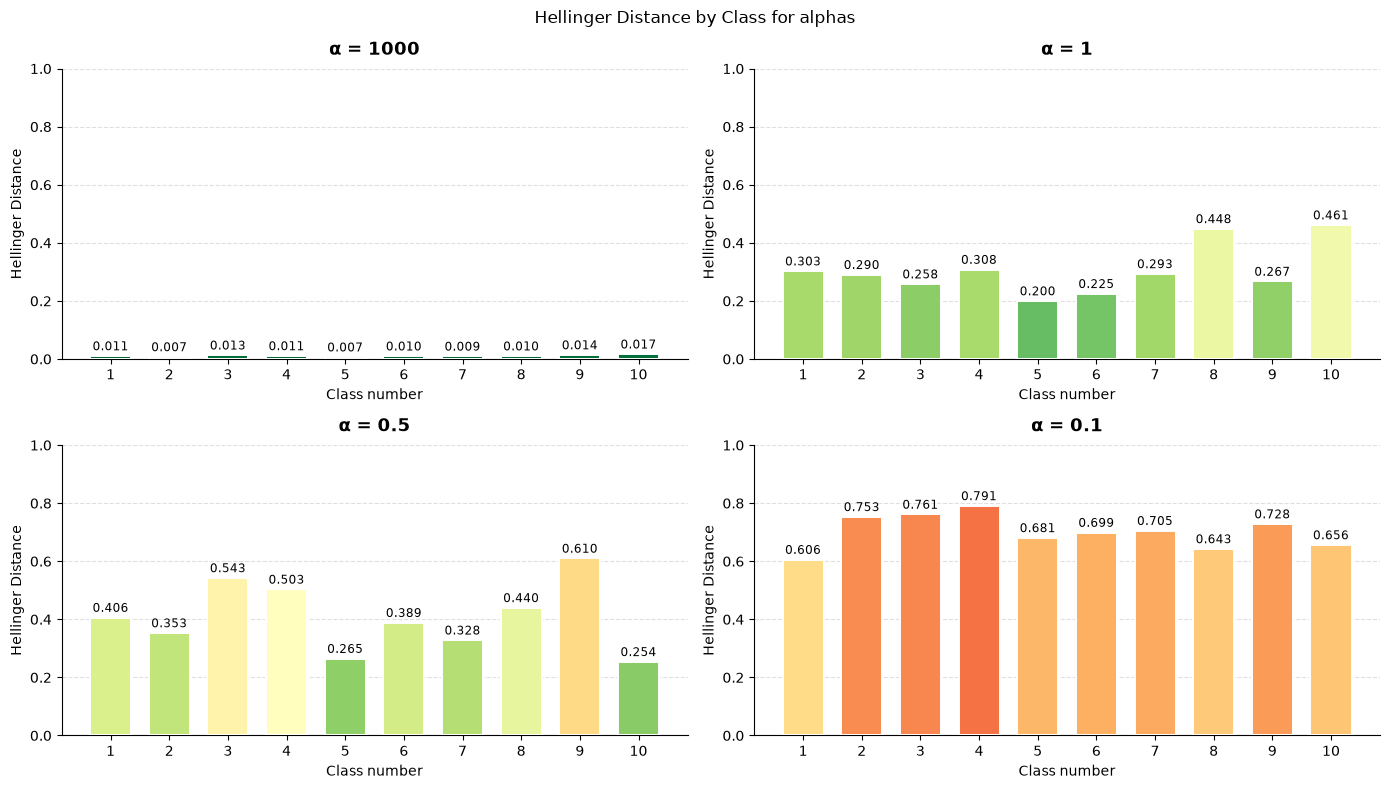

In [21]:
fig, axs = plt.subplots(2, 2, figsize=(14, 8))
cmap = plt.get_cmap('RdYlGn_r')
norm = mcolors.Normalize(vmin=0, vmax=1)

for i, (alpha, p) in enumerate(alphas_class_distributions.items()):

    row = i // 2
    col = i % 2
    ax = axs[row, col]

    hd_results = []

    for j in range(10):
        hd_results.append(HellingerDistance(p[j].numpy().tolist(), baseline))


    colors = [cmap(norm(v)) for v in hd_results]

    bar_container = ax.bar(
        range(1, 11), hd_results,
        color=colors, edgecolor='white', linewidth=1.4, width=0.7,
        zorder=3
    )
    ax.set_title(f'α = {alpha}', fontsize=13, fontweight='bold', pad=10)
    ax.set_ylabel('Hellinger Distance', fontsize=10)
    ax.set_xlabel('Class number', fontsize=10)
    ax.set_ylim(0, 1)
    ax.set_xticks(range(1, 11))

    ax.grid(axis='y', linestyle='--', alpha=0.4, zorder=0)
    ax.set_axisbelow(True)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.bar_label(bar_container, fmt='%.3f', fontsize=8.5, padding=2)

plt.suptitle("Hellinger Distance by Class for alphas")
plt.tight_layout()
plt.show()


We can see how higher concentrations (alpha values) mean fairer distributions in our datasets 

#### 2. Earth Mover's Distance (EMD)

This measurement quantifies the dissimilarity between the frequency distributions, the main idea is that it measures not only the concentration but the position of the distributions (geometrically aware), this of course means that high-dimensional spaces can make this metric too heavy to use.

However our case study raises the issue of having a plane that would represent a discrete and non-quantifiable variable in terms of the label difference (meaning that even if class 1 is numerically closer to class 2 they are not necessarily similar), so we need to performa 1D study, for that we'll use

$$\text{EMD}(p,q) = \sum^{C}_{c=1}{|F_p(c) - F_q(c)|}$$

$$F_p(c) = \sum_{i \leq c} p_i$$

In [22]:
def EMD(p,q,class_count):
    sum = 0
    for c in range(class_count):
        sumpc = np.sum(p[0:c])
        sumqc = np.sum(q[0:c])
        sum += abs(sumpc - sumqc)
    
    return sum

In this scenario we want to compare each client versus the centralized model for all classes

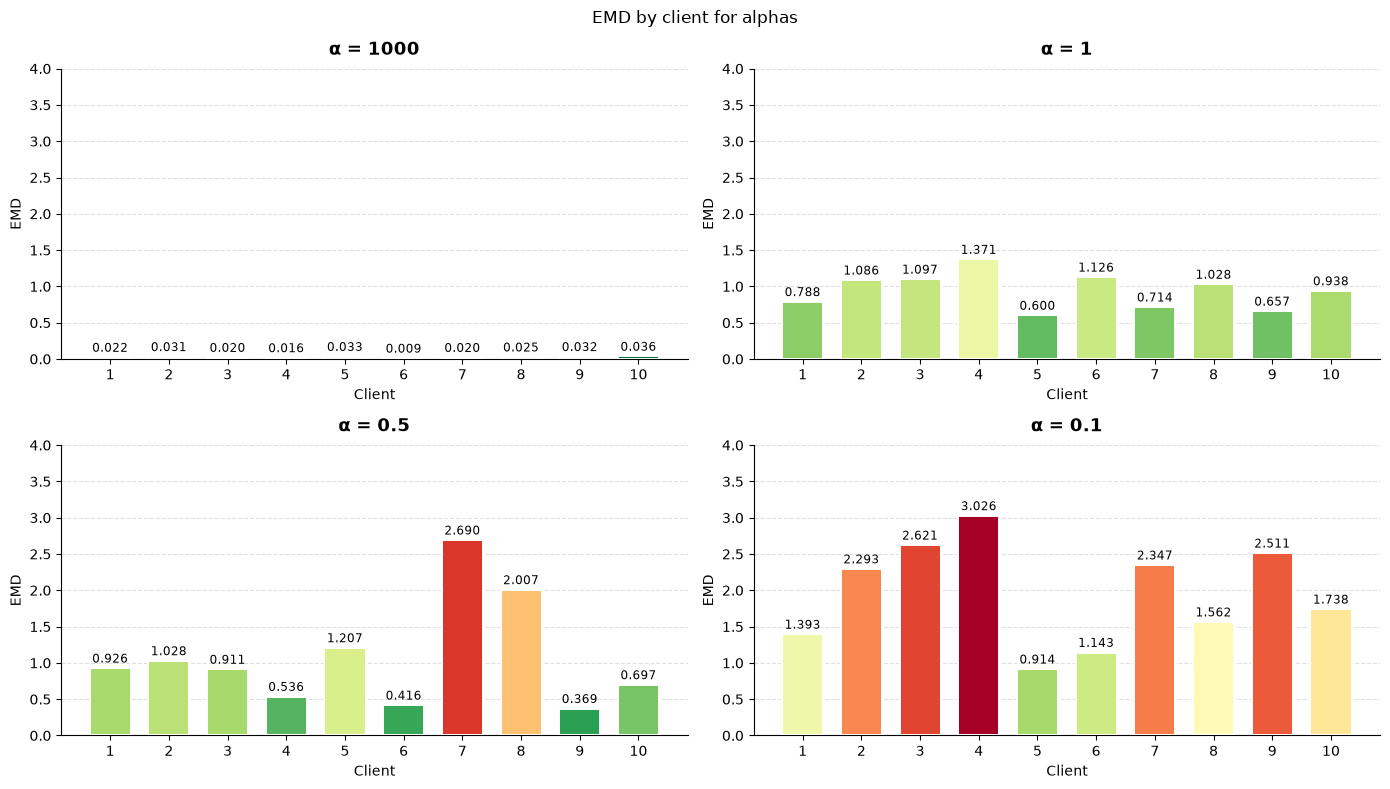

In [23]:
fig, axs = plt.subplots(2, 2, figsize=(14, 8))
cmap = plt.get_cmap('RdYlGn_r')

all_emd_results = {
    alpha: [EMD(client_class_distribution[alpha][j], baseline, 10) for j in range(K)]
    for alpha in alphas_class_distributions
}
global_max = max(v for results in all_emd_results.values() for v in results)
norm = mcolors.Normalize(vmin=0, vmax=global_max) 


for i, (alpha, p) in enumerate(alphas_class_distributions.items()):
    row, col = i // 2, i % 2
    ax = axs[row, col]

    emd_results = [EMD(client_class_distribution[alpha][j], baseline, 10) for j in range(K)]

    colors = [cmap(norm(v)) for v in emd_results]

    bar_container = ax.bar(range(1, 11), emd_results, color=colors, edgecolor='white',
                            linewidth=1.4, width=0.7, zorder=3)
    ax.set_title(f'α = {alpha}', fontsize=13, fontweight='bold', pad=10)
    ax.set_ylabel('EMD', fontsize=10)
    ax.set_xlabel('Client', fontsize=10)
    ax.set_xticks(range(1, 11))
    ax.grid(axis='y', linestyle='--', alpha=0.4, zorder=0)
    ax.set_axisbelow(True)
    ax.set_ylim(0, 4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.bar_label(bar_container, fmt='%.3f', fontsize=8.5, padding=2)

plt.suptitle("EMD by client for alphas")
plt.tight_layout()
plt.show()

We can see some clear patterns across all alphas, even if they have different value magnitudes they almost always have some clients with high label skewness (remember that we are comparing each individual client's class distribution difference versus an ideal baseline scenario). <br> What that means is that some clients are bound to produce biased models when some classes are under/overrepresented, although when EMD values are so low the difference between clients is insignificant because of how similar they are to the ideal case.

#### 3. Jensen-Shannon divergence (JSD)


$$\text{JSD(p,q)} = \frac{1}{2}D_{KL}(p||m) + \frac{1}{2}D_{KL}(q||m), \quad m=\frac{1}{2}(p+q)$$

Where near-zero values mean closer to IID distributions

Although technically not a metric, it does give us some idea of how identical two distributions are. What it does is utilize the [Kullback-Leibler divergence](https://en.wikipedia.org/wiki/Kullback%E2%80%93Leibler_divergence) which measures how much an approximation is different from a true probability distribution.

In [24]:
def D_kl(p,q):
    sum = 0
    for i in range(len(p)):
        if p[i] == 0:
            continue
        sum += p[i] * math.log(p[i]/q[i])
    return sum

def JSD(p,q):
    p = np.array(p)
    q = np.array(q)
    m = 0.5 * (p + q)
    return 0.5 * (D_kl(p,m) + D_kl(q,m))

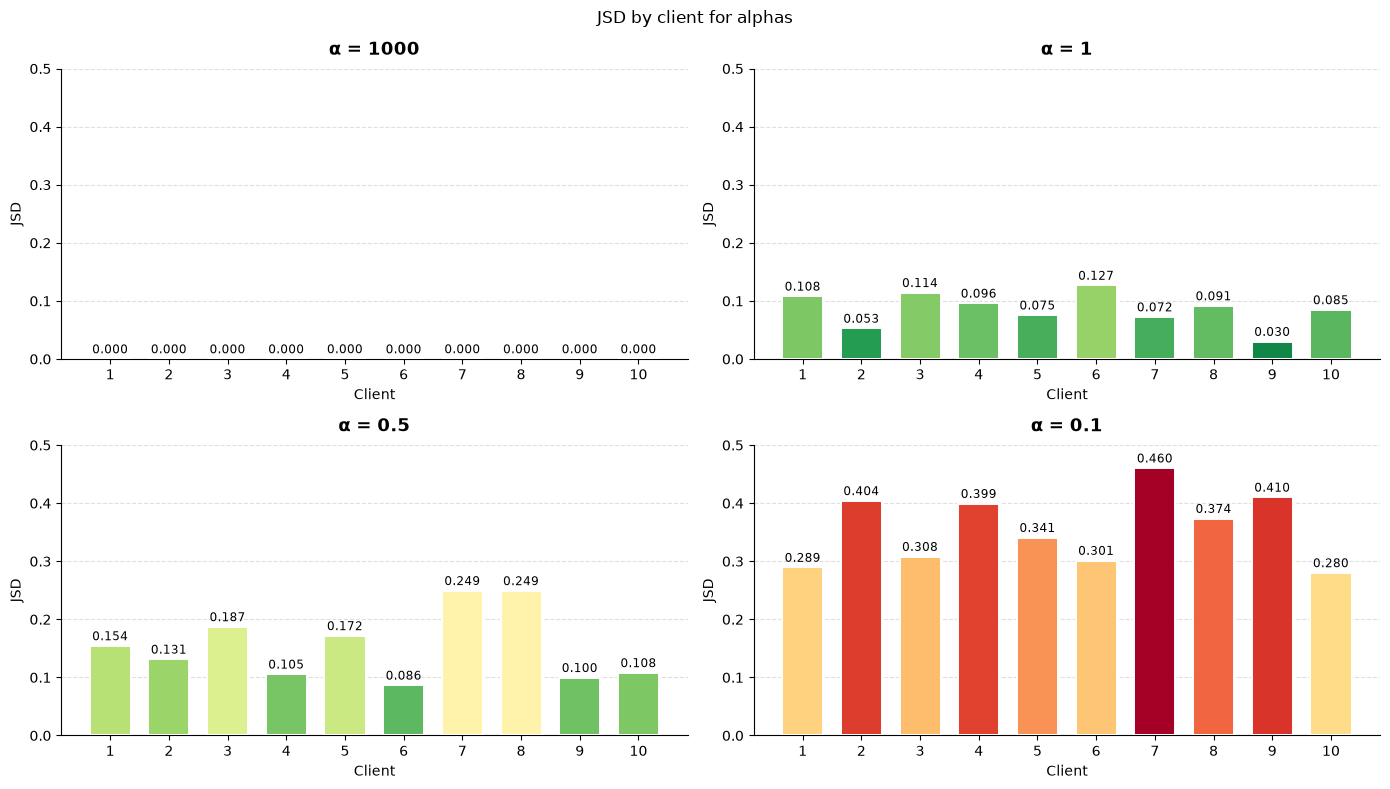

In [25]:
fig, axs = plt.subplots(2, 2, figsize=(14, 8))
cmap = plt.get_cmap('RdYlGn_r')

all_jsd_results = {
    alpha: [JSD(client_class_distribution[alpha][j], baseline) for j in range(K)]
    for alpha in alphas_class_distributions
}
global_max = max(v for results in all_jsd_results.values() for v in results)
norm = mcolors.Normalize(vmin=0, vmax=global_max) 

for i, (alpha, p) in enumerate(alphas_class_distributions.items()):
    row, col = i // 2, i % 2
    ax = axs[row, col]

    jsd_results = all_jsd_results[alpha]

    colors = [cmap(norm(v)) for v in jsd_results]

    bar_container = ax.bar(range(1, 11), jsd_results, color=colors, edgecolor='white',
                            linewidth=1.4, width=0.7, zorder=3)
    ax.set_title(f'α = {alpha}', fontsize=13, fontweight='bold', pad=10)
    ax.set_ylabel('JSD', fontsize=10)
    ax.set_xlabel('Client', fontsize=10)
    ax.set_xticks(range(1, 11))
    ax.grid(axis='y', linestyle='--', alpha=0.4, zorder=0)
    ax.set_axisbelow(True)
    ax.set_ylim(0,0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.bar_label(bar_container, fmt='%.3f', fontsize=8.5, padding=2)

plt.suptitle("JSD by client for alphas")
plt.tight_layout()
plt.show()

#### 4. Population Stability Index

Source: [PSI](https://arxiv.org/pdf/2512.20363)

$$PSI = \sum_{c=1}^{C}{(P(y=c) - P_i(y=c))ln(\frac{P(y=c)}{P_i(y=c)})}$$

In our test case however we can take advantage of the fact that our baseline dataset is equally distributed w/ 10% samples per class, thus reducing the PSI formula to

$$PSI = \sum_{c=1}^{C}{(10\% - P_i(y=c))ln(\frac{10\%}{P_i(y=c)})}$$



In [26]:
def PSI(P_i):
    sum = 0
    for c in range(10):
        if P_i[c] != 0:
            sum += (0.1 - P_i[c]) * math.log(0.1/P_i[c])
        else:
             sum += (0.1 - P_i[c]) * math.log(0.1/0.000001)
    return sum

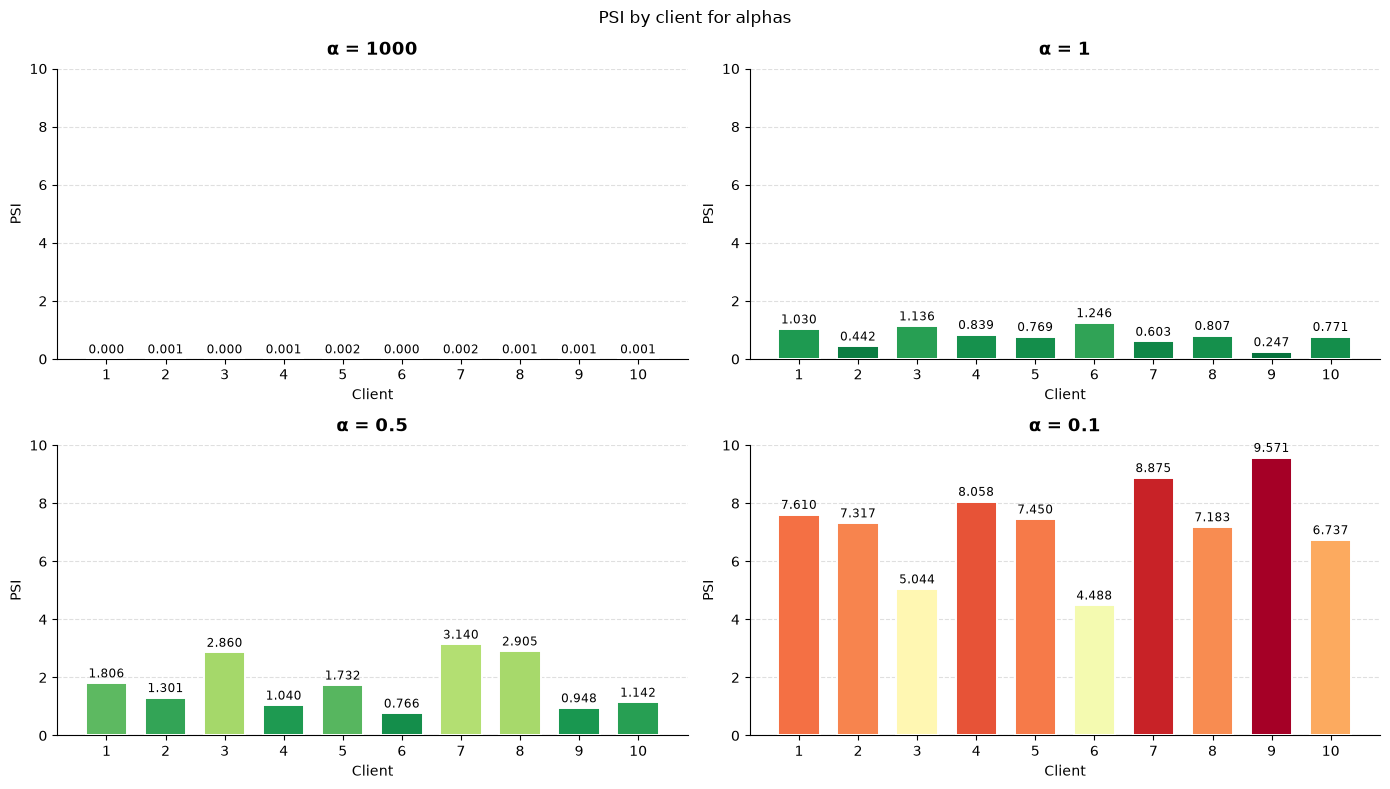

In [30]:
fig, axs = plt.subplots(2, 2, figsize=(14, 8))
cmap = plt.get_cmap('RdYlGn_r')

all_psi_results = {
    alpha: [PSI(client_class_distribution[alpha][j]) for j in range(K)]
    for alpha in alphas_class_distributions
}

global_max = max(v for results in all_psi_results.values() for v in results)
norm = mcolors.Normalize(vmin=0, vmax=global_max) 


for i, (alpha, p) in enumerate(alphas_class_distributions.items()):
    row, col = i // 2, i % 2
    ax = axs[row, col]

    psi_results = all_psi_results[alpha]

    colors = [cmap(norm(v)) for v in psi_results]

    bar_container = ax.bar(range(1, 11), psi_results, color=colors, edgecolor='white',
                            linewidth=1.4, width=0.7, zorder=3)
    ax.set_title(f'α = {alpha}', fontsize=13, fontweight='bold', pad=10)
    ax.set_ylabel('PSI', fontsize=10)
    ax.set_xlabel('Client', fontsize=10)
    ax.set_xticks(range(1, 11))
    ax.grid(axis='y', linestyle='--', alpha=0.4, zorder=0)
    ax.set_axisbelow(True)
    ax.set_ylim(0,10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.bar_label(bar_container, fmt='%.3f', fontsize=8.5, padding=2)

plt.suptitle("PSI by client for alphas")
plt.tight_layout()
plt.show()


#### 5. Bubble Chart

Using a standard bubble chart display can also help us easily spot the vast differences between concentration values when splitting the dataset amongst clients

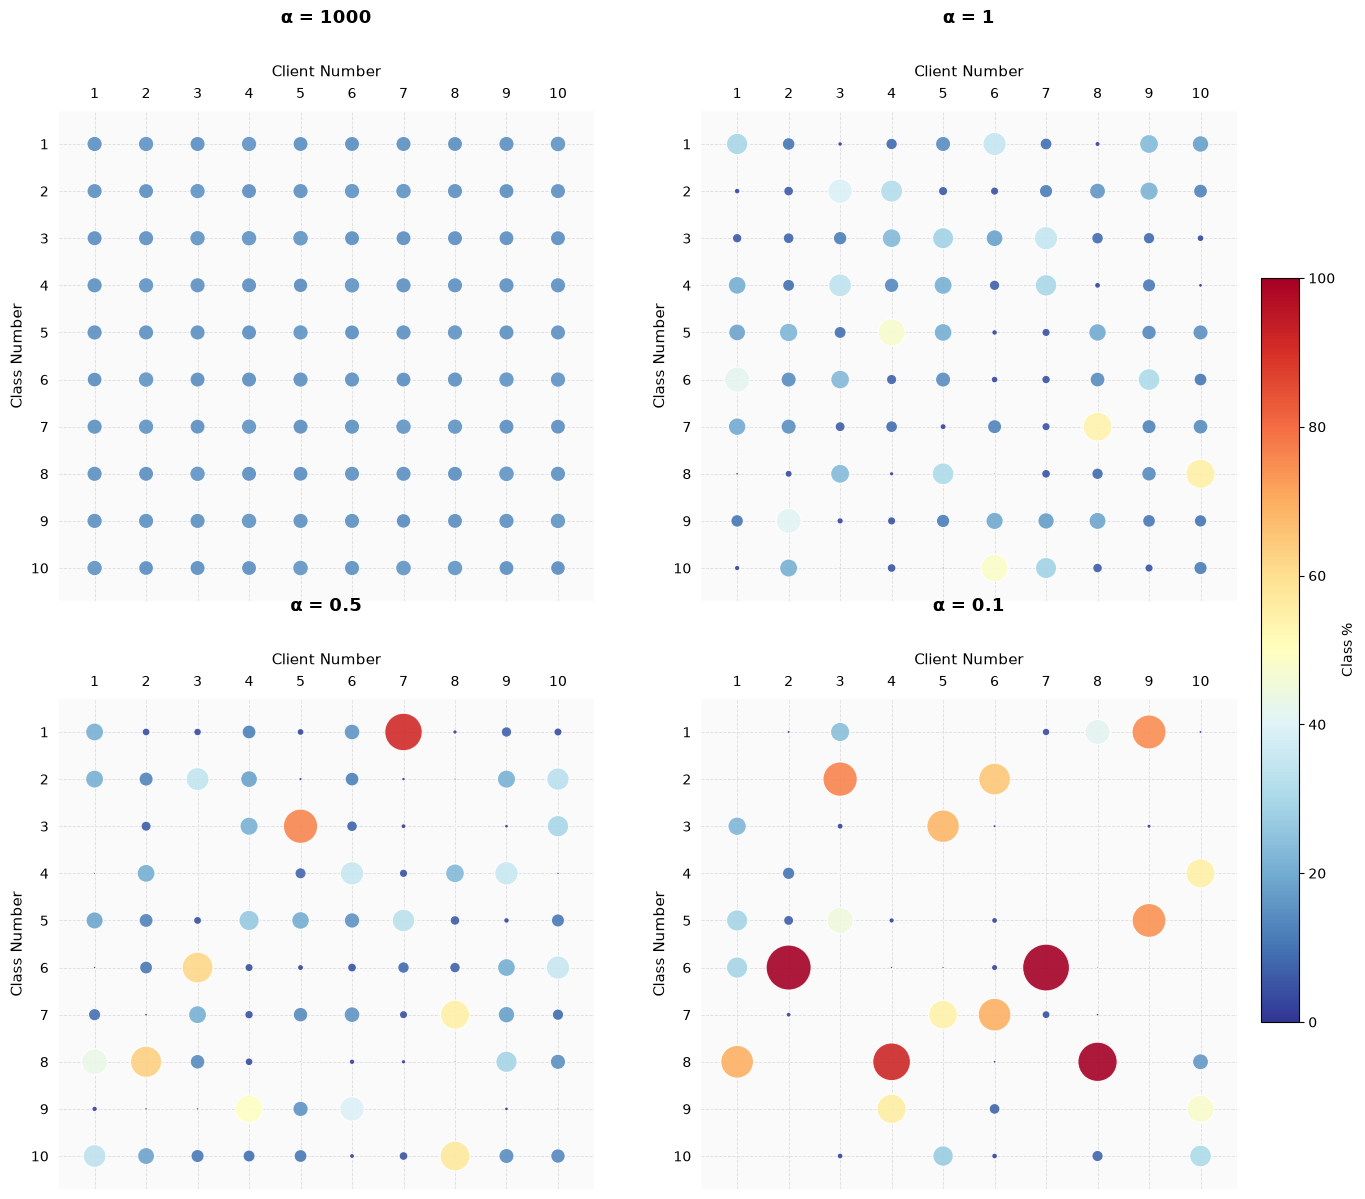

In [31]:
fig, axs = plt.subplots(2, 2, figsize=(16, 14))

cmap = plt.get_cmap('RdYlBu_r') 
norm = mcolors.Normalize(vmin=0, vmax=100)

for i, alpha in enumerate(client_class_distribution.keys()):
    row, col = i // 2, i % 2
    ax = axs[row, col]

    alpha_client_class_distributions = client_class_distribution[alpha]

    data = {
        (class_num, client_num): alpha_client_class_distributions[client_num - 1][class_num - 1]
        for class_num in range(1, 11)
        for client_num in range(1, 11)
    }

    x_clients = [key[1] for key in data.keys()]
    y_classes = [key[0] for key in data.keys()]
    scalars   = [v * 150 for v in data.values()]

    sizes = [s * 8 for s in scalars]

    ax.set_facecolor('#fafafa')
    ax.grid(True, linestyle='--', linewidth=0.6, color='#ddd', zorder=0)

    sc = ax.scatter(
        x_clients,
        y_classes,
        s=sizes,
        c=scalars,
        cmap=cmap,
        norm=norm,
        alpha=0.9,
        edgecolors='white',
        linewidths=0.8,
        zorder=3
    )

    ticks = list(range(1, 11))
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    ax.set_xlabel('Client Number', fontsize=11, labelpad=8)
    ax.set_ylabel('Class Number', fontsize=11)

    ax.xaxis.tick_top()
    ax.xaxis.set_label_position('top')
    ax.invert_yaxis()

    ax.tick_params(top=False, bottom=False, left=False, right=False)
    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.set_xlim(0.3, 10.7)
    ax.set_ylim(10.7, 0.3)

    ax.set_title(f'α = {alpha}', fontsize=13, fontweight='bold', pad=30)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axs, fraction=0.03, pad=0.02)
cbar.set_label('Class %', fontsize=10)

plt.show()

What we see here is pretty much just a visualization of what we already knew, high-concentration alphas distribute all classes as equally as possible across clients, making them all (hopefully) produce a somewhat fair model. However, as concentrations get lower we see big clusters forming and clients loosing all data on certain classes, this is double the harm as it causes overfitting and biased models.

#### 6. Total Quantity

A final but important side-effect of Non-IID scenarios is that they not only impact the label-specific distributions but the overall sample numbers. While this is does not necessarily mean that the local models will be biased towards one class they strongly favor overfitting.

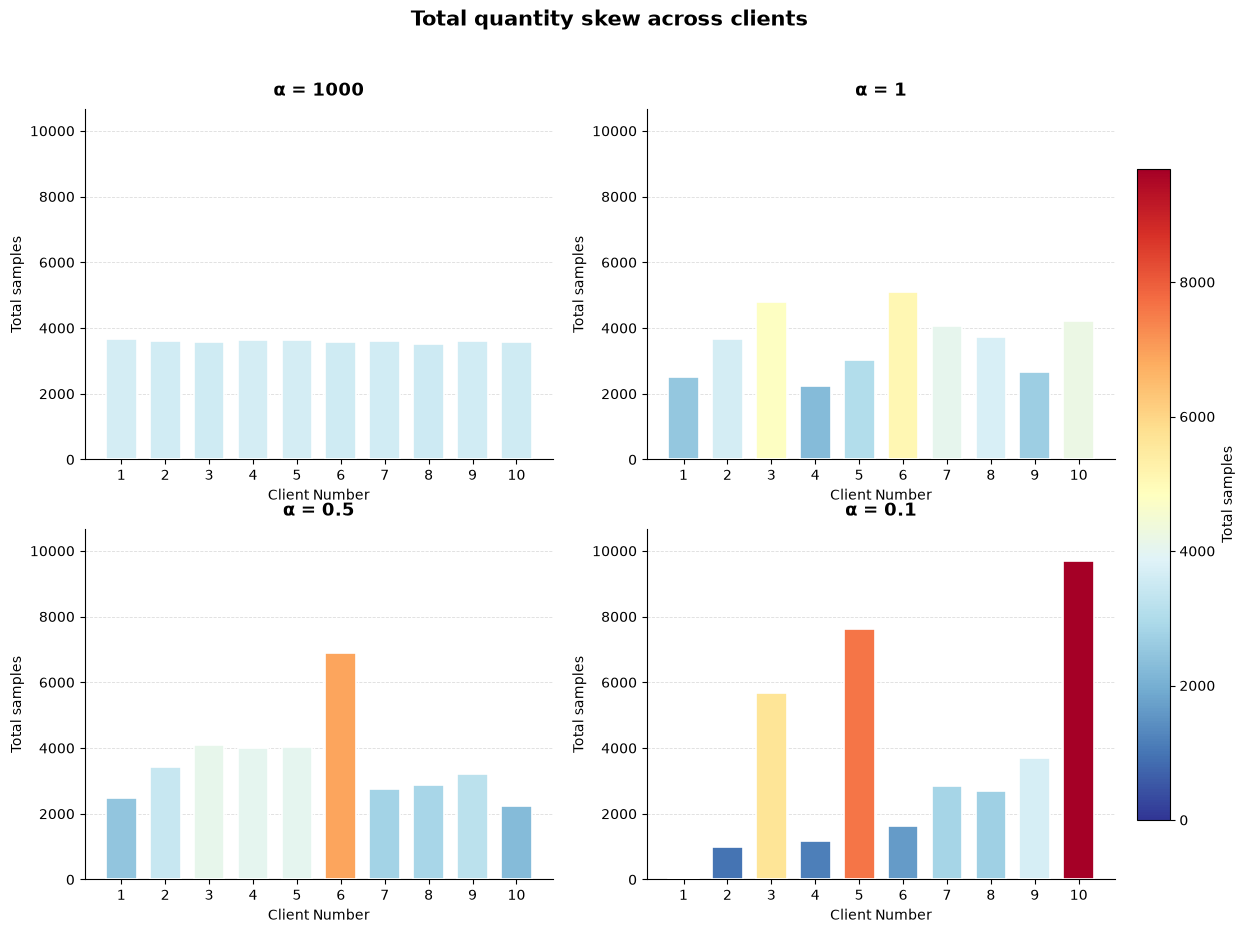

In [32]:
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

cmap = plt.get_cmap('RdYlBu_r')

all_totals = {
    alpha: [sum(alpha_client_class_counts[alpha][i]) for i in range(K)]
    for alpha in alpha_client_class_counts
}
global_max = max(v for totals in all_totals.values() for v in totals)
norm = mcolors.Normalize(vmin=0, vmax=global_max)

for i, alpha in enumerate(alpha_client_class_counts.keys()):
    row, col = i // 2, i % 2
    ax = axs[row, col]

    totals = all_totals[alpha]
    colors = [cmap(norm(v)) for v in totals]

    ax.bar(
        range(1, K + 1), totals,
        color=colors, edgecolor='white', linewidth=1.2, width=0.7,
        zorder=3
    )

    ax.set_title(f'α = {alpha}', fontsize=13, fontweight='bold', pad=10)
    ax.set_ylabel('Total samples', fontsize=10)
    ax.set_xlabel('Client Number', fontsize=10)
    ax.set_ylim(0, global_max * 1.1)
    ax.set_xticks(range(1, K + 1))
    ax.grid(True, axis='y', linestyle='--', linewidth=0.6, color='#ddd', zorder=0)
    ax.set_axisbelow(True)

    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axs, fraction=0.03, pad=0.02)
cbar.set_label('Total samples', fontsize=10)

plt.suptitle('Total quantity skew across clients', fontsize=15, fontweight='bold', y=0.98)
plt.show()

Note how a high concentration $\alpha = 1000$ shows an almost perfect grid, this has a slight fluctuation when lowered to $\alpha = 1$, then starts to show a few highly-skewed classes in $\alpha = 0.5$ and finally transforms into a completely imbalanced scenario for $\alpha = 0.1$

#### Takeaway

While all these metrics are different and highlight varying issues they consistently raise the same question, ***how should clients be valued***?

When we perform a model generalization it is imperative that we take into account the fact that not all clients are as valuable (or even have good intentions), which makes the task of federated learning even more difficult. It is a fact that if we treated all models as if they were equally important then we would end up with rich models being completely botchered by ill-fitted models (whether that is because of low sample counts, bias in classes or malign actors). This can slow down the convergence towards a singular best-suited centralized model.

## Local Models training

Having the local datasets we can train each of the client's models and see their performance across the Adam & SGD optimizers

### Adam-Optimized Models

In [33]:
best_performing_clients_Adam = {}

for alpha, clients_datasets in alpha_clients_datasets.items(): #For all densities

    clients_Adam_metrics = []
    models = []

    for client_index in range(K):  # For each client

        # We define a model using Adam optimizer
        client_Adam_model = copy.deepcopy(initial_model)
        Adam_optimizer = torch.optim.Adam(client_Adam_model.parameters())

        client_train_loader = DataLoader(clients_datasets[client_index]["train"], batch_size=32, shuffle=True)
        client_val_loader = DataLoader(clients_datasets[client_index]["val"], batch_size=32, shuffle=True)

        # We keep themetrics
        clients_Adam_metrics.append(run_model(client_Adam_model, Adam_optimizer, epochs=100, train_dataloader=client_train_loader, val_dataloader=client_val_loader))
        models.append(client_Adam_model)

    # We pick the client w/ max accuracy 
    best_client_index, (best_train_metrics, best_val_metrics) = max(
        enumerate(clients_Adam_metrics),
        key=lambda item: item[1][1][-1][0]  
    )

    best_performing_clients_Adam[alpha] = {
        "client_index": best_client_index,
        "train_metrics": best_train_metrics,
        "val_metrics": best_val_metrics,
        "model": models[best_client_index]
    }


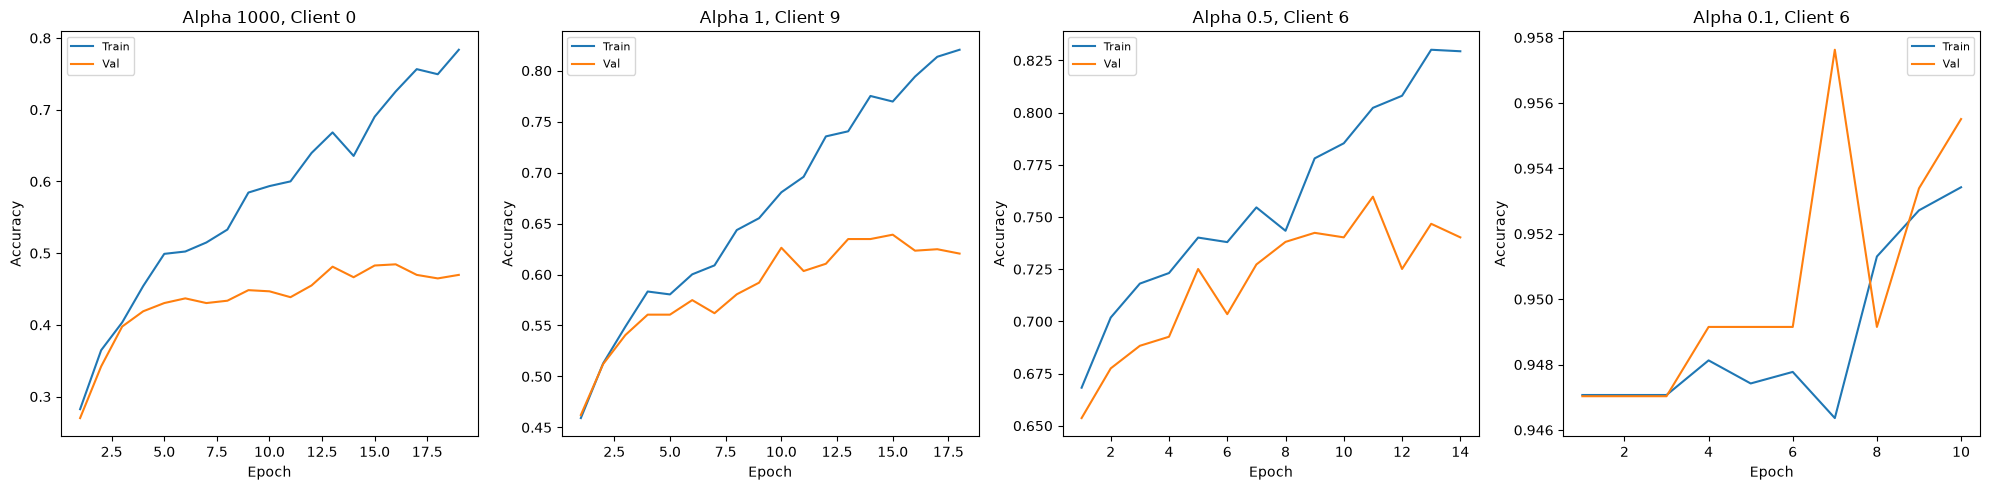

In [34]:
fig, axes = plt.subplots(1, 4, figsize=(20,5))

for i,(alpha, dict) in enumerate(best_performing_clients_Adam.items()):
    client_index = dict["client_index"]
    train_metrics, val_metrics = dict["train_metrics"], dict["val_metrics"]
    train_acc = [acc for acc, loss in train_metrics]
    val_acc = [acc for acc, loss in val_metrics]
    epochs_range = range(1, len(train_acc) + 1)

    ax = axes[i]
    ax.plot(epochs_range, train_acc, label="Train", color="tab:blue")
    ax.plot(epochs_range, val_acc, label="Val", color="tab:orange")
    ax.set_title(f"Alpha {alpha}, Client {client_index}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

#### Confusion Matrix

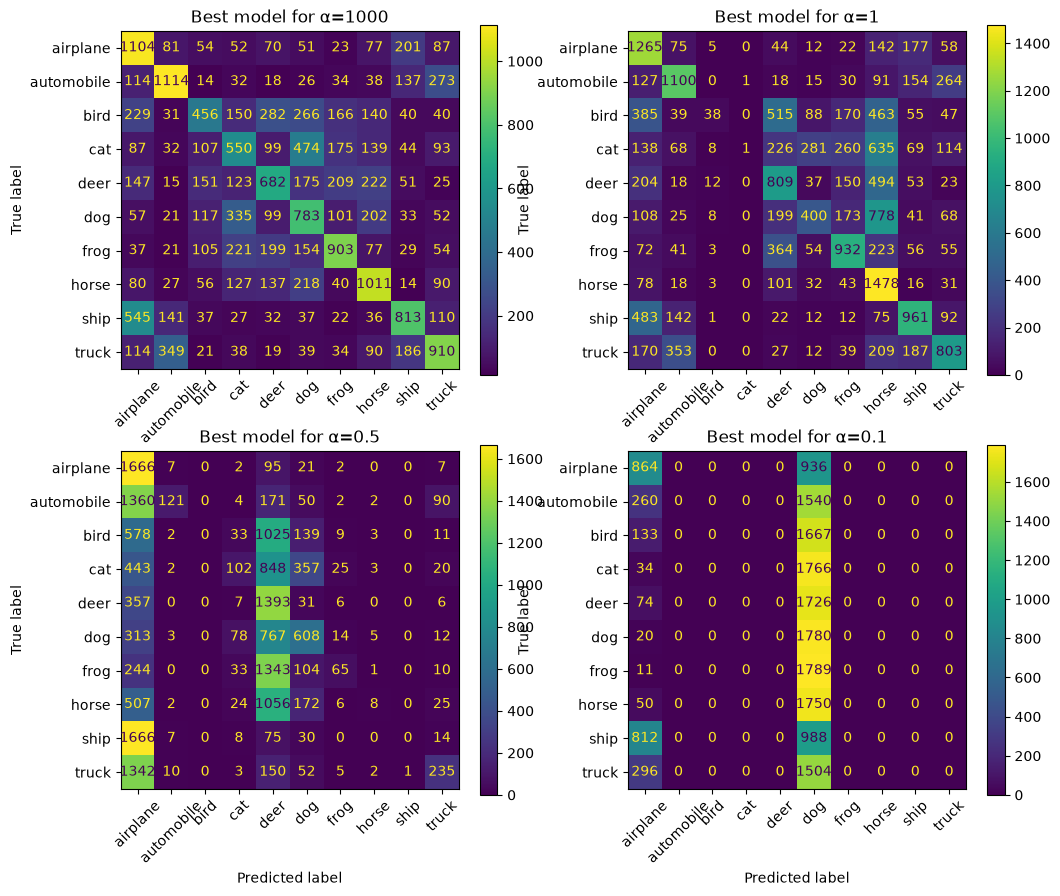

In [35]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))

ax_flat = axes.flatten() 

for i, (alpha, best) in enumerate(best_performing_clients_Adam.items()):
    plot_cm(model=best["model"], dataLoader=test_dataloader, title=f"Best model for α={alpha}", ax=ax_flat[i])

What this shows is not unexpected, when we have a high alpha our clients are closer to the ideal scenario and thus perform similarly to the centralized baseline (although there still is a quantity skewness that impacts the model's performance). Then, as we progress into unequally distributed datasets, almost none of the clients can provide meaningful data because models become overfitted at best. 

In the big picture however, one could try to average models that overfit in disjoint classes to get a more general one, this would easily out-perform what clients would normally get if they decided to just train models on their own (assuming of course that raw data must not be disclosed) and is why Federated Learning is so beneficial in fields were raw data is completely secured, such as hospitals, banks, etc.

### SGD-Optimized Models

In [36]:
best_performing_clients_SGD = {}

for alpha, clients_datasets in alpha_clients_datasets.items(): #For all densities

    clients_SGD_metrics = []
    models = []

    for client_index in range(K):  # For each client

        # We define a model using SGD optimizer
        client_SGD_model = copy.deepcopy(initial_model)
        SGD_optimizer = torch.optim.SGD(client_SGD_model.parameters(), momentum=0.9)

        client_train_loader = DataLoader(clients_datasets[client_index]["train"], batch_size=32, shuffle=True)
        client_val_loader = DataLoader(clients_datasets[client_index]["val"], batch_size=32, shuffle=True)

        # We keep the metrics
        clients_SGD_metrics.append(run_model(client_SGD_model, SGD_optimizer, epochs=100, train_dataloader=client_train_loader, val_dataloader=client_val_loader))
        models.append(client_SGD_model)

    # We pick the client w/ max accuracy 
    best_client_index, (best_train_metrics, best_val_metrics) = max(
        enumerate(clients_SGD_metrics),
        key=lambda item: item[1][1][-1][0]  
    )

    best_performing_clients_SGD[alpha] = {
        "client_index": best_client_index,
        "train_metrics": best_train_metrics,
        "val_metrics": best_val_metrics,
        "model": models[best_client_index]
    }


#### Confusion Matrix

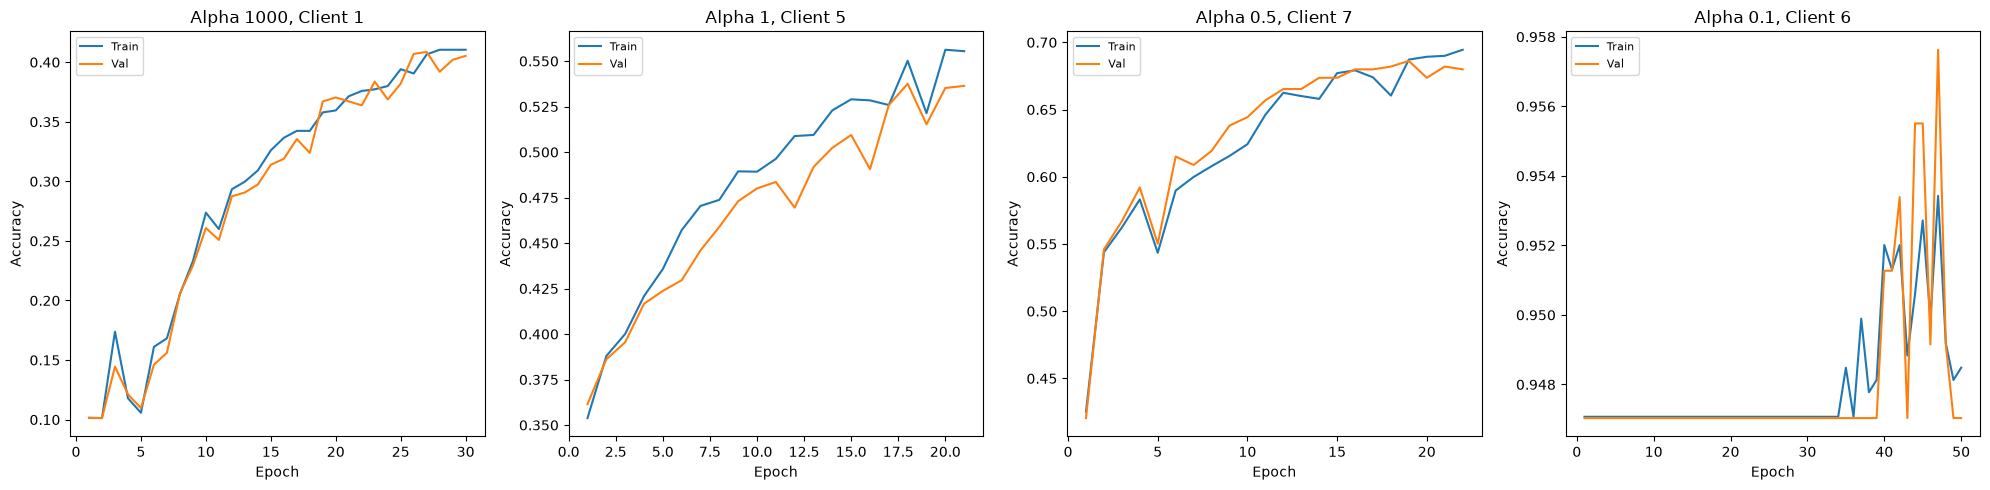

In [37]:
fig, axes = plt.subplots(1, 4, figsize=(20,5))

for i,(alpha, dict) in enumerate(best_performing_clients_SGD.items()):
    client_index = dict["client_index"]
    train_metrics, val_metrics = dict["train_metrics"], dict["val_metrics"]
    train_acc = [acc for acc, loss in train_metrics]
    val_acc = [acc for acc, loss in val_metrics]
    epochs_range = range(1, len(train_acc) + 1)

    ax = axes[i]
    ax.plot(epochs_range, train_acc, label="Train", color="tab:blue")
    ax.plot(epochs_range, val_acc, label="Val", color="tab:orange")
    ax.set_title(f"Alpha {alpha}, Client {client_index}")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

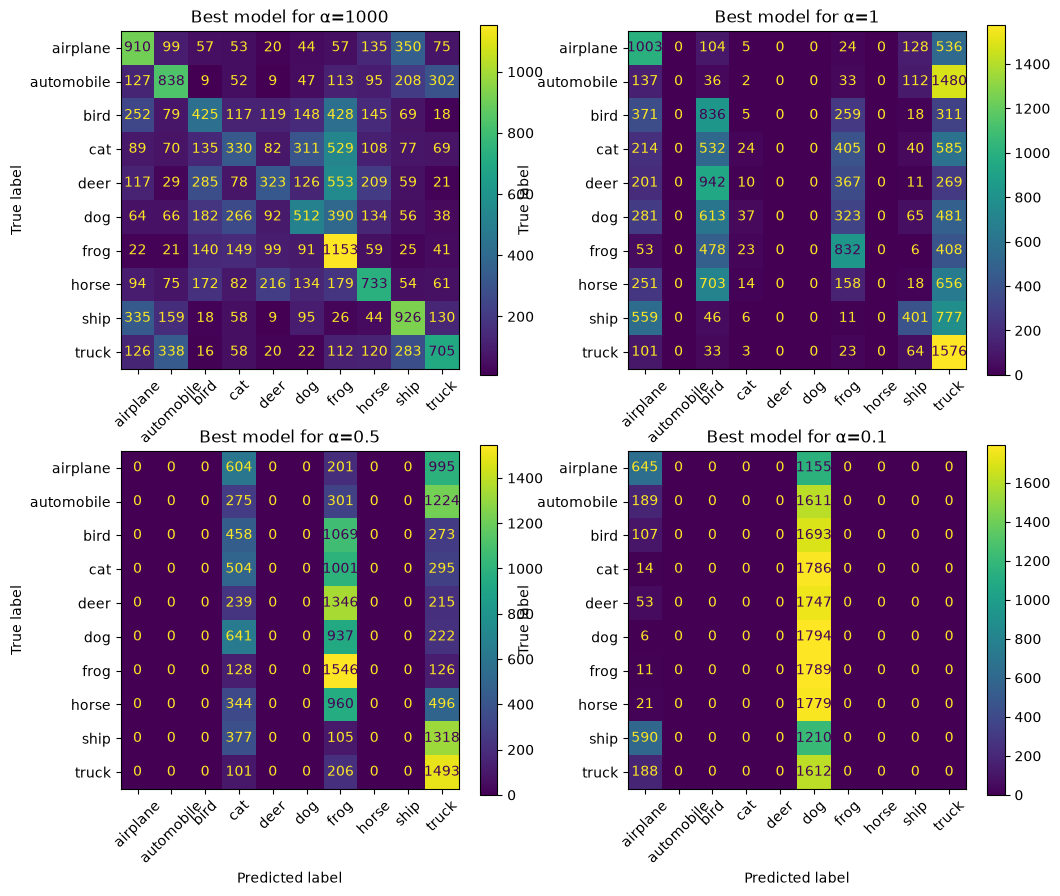

In [38]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))

ax_flat = axes.flatten() 

for i, (alpha, best) in enumerate(best_performing_clients_SGD.items()):
    plot_cm(model=best["model"], dataLoader=test_dataloader, title=f"Best model for α={alpha}", ax=ax_flat[i])

In a pretty similar fashion to what the Adam-Optimized client's models did, we can see that when data is equally distributed almost all models perform ideally. Although in this case, our top-performing $\alpha=1000$ model has a slightly weaker diagonal it still performs exceptionally well compared to other scenarios. 

## Federated Learning Aggregation Strategies

We will utilize [Flower Framework's strategies](https://flower.ai/docs/framework/1.35/en/ref-api/flwr.serverapp.strategy.html) to implement a few federated aggregation strategies

First off, we define a common model to which we'll load the computed weights from the different final models to calculate the comparison metrics.

In [39]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(3, 8, (7, 7), padding="same", stride=1),
            nn.ReLU(),
            nn.AvgPool2d(kernel_size=(2, 2)),
            nn.Conv2d(8, 16, (5, 5), padding="same", stride=1),
            nn.ReLU(),
            nn.AvgPool2d(kernel_size=(2, 2)),
            nn.Conv2d(16, 32, (3, 3), padding="same", stride=1),
            nn.ReLU(),
            nn.Flatten(),
            nn.Dropout(p=0.3),
            nn.Linear(2048, 128),
            nn.Dropout(p=0.3),
            nn.Linear(128, 64),
            nn.Linear(64, 10),
            nn.LogSoftmax(dim=1),
        )

    def forward(self, x):
        return self.model(x)

alphas = [0.1,0.5,1,1000]
seeds = [27,42,143]


### 1. FedAvg

$$FedAvg(C,E,B)$$

The main idea behind this algorithm is to take a fraction of the clients $C$ and then make each client locally take E steps of gradient descent on the current model using its local data in batches of size B, then the server takes a weighted average of the resulting models.

_Source: [Communication-Efficient Learning of Deep Networks
from Decentralized Data](https://arxiv.org/pdf/1602.05629)_ <br>_by H. Brendan McMahan, Eider Moore, Daniel Ramage, Seth Hampson, Blaise Agüera y Arcas_

In [40]:
device = torch.device("cpu")
fedAvgModel = Net()
fedAvgAccuracies = {1000: [], 1: [], 0.5:[], 0.1:[]}
fedAvgMeans = {}
fedAvgStds = {}

for alpha in alphas:
    for seed in seeds:
        fedAvgstate_dict = torch.load(f"./Aggregation_Strategies/FedAvg/models/fedavg_alpha_{alpha}_seed_{seed}.pt", map_location=torch.device('cpu'))
        fedAvgModel.load_state_dict(fedAvgstate_dict)        
        fedAvgModel.to(device)
        (fedAvgAccuracy, fedAvgLoss) = test(fedAvgModel, test_dataloader,torch.nn.CrossEntropyLoss())
        fedAvgAccuracies[alpha].append(fedAvgAccuracy)
        

for alpha in fedAvgAccuracies.keys():
    fedAvgMeans[alpha] = np.mean(fedAvgAccuracies[alpha])
    fedAvgStds[alpha] = np.std(fedAvgAccuracies[alpha])


### 2. FedProx

$$FedProx(C,E,B, \mu)$$

This algorithm has only one difference to FedAvg, which is that it allows variable amounts of work to be performed locally across devices (based on their available system resources), aggregating those "partial" solutions which would normally be dropped by FedAvg. This is partly because FedAvg has the problem of fixing a common local epoch objective which can raise an issue in convergence speed if set too low or overfitted models if the epochs are too high.

_Source: [Federated Optimization in Heterogeneous Networks](https://arxiv.org/pdf/1812.06127)_ <br>_by Tian Li, Anit Kumar Sahu, Manzil Zaheer, Maziar Sanjabi, Ameet Talwalkar, Virginia Smith_

A grid search is done with the following values:

$\mu = \{0.01, 0.1, 0.5\}$

In [50]:
mu_values = [0.01, 0.1, 0.5]

device = torch.device("cpu")
fedProxModel = Net()

for mu in mu_values:
    fedProxstate_dict = torch.load(f"./Aggregation_Strategies/FedProx/grid-search-models/fedProx_mu_{mu}.pt", map_location=torch.device('cpu'))
    fedProxModel.load_state_dict(fedProxstate_dict)        
    fedProxModel.to(device)
    (fedProxAccuracy, fedProxLoss) = test(fedProxModel, test_dataloader,torch.nn.CrossEntropyLoss())
    print(f"Mu: {mu}      Accuracy: {fedProxAccuracy}")

Mu: 0.01      Accuracy: 0.5618333333333333
Mu: 0.1      Accuracy: 0.46344444444444444
Mu: 0.5      Accuracy: 0.3205


We can see that for $\mu=0.01$ we get the highest accuracy, so we'll use that hyperparameter for our study

In [42]:
device = torch.device("cpu")
fedProxModel = Net()
fedProxAccuracies = {1000: [], 1: [], 0.5:[], 0.1:[]}
fedProxMeans = {}
fedProxStds = {}


for alpha in alphas:
    for seed in seeds:
        fedProxstate_dict = torch.load(f"./Aggregation_Strategies/FedProx/models/fedProx_alpha_{alpha}_seed_{seed}.pt", map_location=torch.device('cpu'))
        fedProxModel.load_state_dict(fedProxstate_dict)        
        fedProxModel.to(device)
        (fedProxAccuracy, fedProxLoss) = test(fedProxModel, test_dataloader,torch.nn.CrossEntropyLoss())
        fedProxAccuracies[alpha].append(fedProxAccuracy)
        

for alpha in fedProxAccuracies.keys():
    fedProxMeans[alpha] = np.mean(fedProxAccuracies[alpha])
    fedProxStds[alpha] = np.std(fedProxAccuracies[alpha])


### 3. FedAvgM

$$FedAvgM(\beta)$$

FedAvgM runs FedAvg with momentum, basically changing the way each update is performed by modifying its equation as follows:

$FedAvg:$
$$w ← w -  ∆ w$$

$FedAvgM:$
1. $$   v_t ← \beta v_{t-1} + ∆ w $$
2. $$   w  ← w - v_t$$

_Source: [Measuring the Effects of Non-Identical Data Distribution for Federated Visual Classification](https://arxiv.org/abs/1909.06335)_ <br>_by Tzu-Ming Harry Hsu, Hang Qi, Matthew Brown_

In this case we'll use the following possible values:

$\beta = \{ 0.1, 0.97, 0.5\}$

In [49]:
beta_values = [0.1, 0.97, 0.5]

device = torch.device("cpu")
fedAvgMModel = Net()

for beta in beta_values:
    fedAvgMstate_dict = torch.load(f"./Aggregation_Strategies/FedAvgM/grid-search-models/fedAvgM_beta_{beta}.pt", map_location=torch.device('cpu'))
    fedAvgMModel.load_state_dict(fedAvgMstate_dict)        
    fedAvgMModel.to(device)
    (fedAvgMAccuracy, fedAvgMLoss) = test(fedAvgMModel, test_dataloader,torch.nn.CrossEntropyLoss())
    print(f"Beta: {beta}      Accuracy: {fedAvgMAccuracy}")

Beta: 0.1      Accuracy: 0.5518333333333333
Beta: 0.97      Accuracy: 0.4066666666666667


FileNotFoundError: [Errno 2] No such file or directory: './Aggregation_Strategies/FedAvgM/grid-search-models/fedAvgM_beta_0.5.pt'

We'll be using $\beta = 0.1$ as it yields the highest accuracy.

In [44]:
device = torch.device("cpu")
fedAvgMModel = Net()
fedAvgMAccuracies = {1000: [], 1: [], 0.5:[], 0.1:[]}
fedAvgMMeans = {}
fedAvgMStds = {}

for alpha in alphas:
    for seed in seeds:
        fedAvgMstate_dict = torch.load(f"./Aggregation_Strategies/FedAvgM/models/fedAvgM_alpha_{alpha}_seed_{seed}.pt", map_location=torch.device('cpu'))
        fedAvgMModel.load_state_dict(fedAvgMstate_dict)        
        fedAvgMModel.to(device)
        (fedAvgMAccuracy, fedAvgMLoss) = test(fedAvgMModel, test_dataloader,torch.nn.CrossEntropyLoss())
        fedAvgMAccuracies[alpha].append(fedAvgMAccuracy)
        

for alpha in fedAvgMAccuracies.keys():
    fedAvgMMeans[alpha] = np.mean(fedAvgMAccuracies[alpha])
    fedAvgMStds[alpha] = np.std(fedAvgMAccuracies[alpha])


### 4. FedAdam

$$FedAdam(LR, \tau, {\beta}_1, {\beta}_2)$$

This strategy employs Adam over SGD as the optimizer. In this case FedAdam only modifies the server's optimizer while the clients maintain an SGD-based optimization.

It basically computes the following:

$$v_t = {\beta}_2 v_{t-1} + (1-{\beta}_2)∆^2_t$$

_Source: [Adaptive Federated Optimization](https://arxiv.org/pdf/2003.00295v5)_ <br>_by Sashank Reddi, Zachary Charles, Manzil Zaheer, Zachary Garrett, Keith Rush, Jakub Konečný, Sanjiv Kumar, H. Brendan McMahan_

For our grid-search we will be using the following values:

1.  $(0.1, 0.01, 0.99, 0.99)$
2.  $(0.1, 0.01, 0.75, 0.75)$
3.  $(0.01, 0.01, 0.99, 0.99)$
4.  $(0.1, 0.1, 0.99, 0.99)$

In [45]:
cases = [(0.1,0.01,0.99,0.99), (0.1,0.01,0.75,0.75), (0.01,0.01,0.99,0.99),(0.1,0.1,0.99,0.99)]

device = torch.device("cpu")
fedAdamModel = Net()

for (eta, tau, beta_1, beta_2) in cases:
    fedAdamstate_dict = torch.load(f"./Aggregation_Strategies/FedAdam/grid-search-models/fedAdam_eta_{eta}_tau_{tau}_beta1_{beta_1}_beta2_{beta_2}.pt", map_location=torch.device('cpu'))
    fedAdamModel.load_state_dict(fedAdamstate_dict)        
    fedAdamModel.to(device)
    (fedAdamAccuracy, fedAdamLoss) = test(fedAdamModel, test_dataloader,torch.nn.CrossEntropyLoss())
    print(f"Case: {(eta,tau,beta_1,beta_2)}      Accuracy: {fedAdamAccuracy}")

Case: (0.1, 0.01, 0.99, 0.99)      Accuracy: 0.39022222222222225
Case: (0.1, 0.01, 0.75, 0.75)      Accuracy: 0.3716111111111111
Case: (0.01, 0.01, 0.99, 0.99)      Accuracy: 0.16794444444444445
Case: (0.1, 0.1, 0.99, 0.99)      Accuracy: 0.2848333333333333


In [46]:
device = torch.device("cpu")
fedAdamModel = Net()
fedAdamAccuracies = {1000: [], 1: [], 0.5:[], 0.1:[]}
fedAdamMeans = {}
fedAdamStds = {}

for alpha in alphas:
    for seed in seeds:
        fedAdamstate_dict = torch.load(f"./Aggregation_Strategies/FedAdam/models/fedAdam_alpha_{alpha}_seed_{seed}.pt", map_location=torch.device('cpu'))
        fedAdamModel.load_state_dict(fedAdamstate_dict)        
        fedAdamModel.to(device)
        (fedAdamAccuracy, fedAdamLoss) = test(fedAdamModel, test_dataloader,torch.nn.CrossEntropyLoss())
        fedAdamAccuracies[alpha].append(fedAdamAccuracy)
        

for alpha in fedAdamAccuracies.keys():
    fedAdamMeans[alpha] = np.mean(fedAdamAccuracies[alpha])
    fedAdamStds[alpha] = np.std(fedAdamAccuracies[alpha])

### 5. FedPer

$$FedPer$$

FedPer essentially performs fine-tuning on the top layers -with stochastic gradient descent- of the general distributed model built around a standard (or modified) federated averaging strategy

This actually poses a bit of an issue because there is no global model to compare it to, the whole idea of FedPer is that it's strength lies in the local models' personalization. 

What we can do however is get an average 

_Source: [Federated Learning with Personalization Layers](https://arxiv.org/pdf/1912.00818)_ <br>_by Manoj Ghuhan Arivazhagan, Vinay Aggarwal, Aaditya Kumar Singh, Sunav Choudhary_

In [47]:
device = torch.device("cpu")
fedPerModel = Net()
fedPerAccuracies = []

for alpha in alphas:
    for seed in seeds:
        fedPerstate_dict = torch.load(f"./Aggregation_Strategies/FedPer/fedper_alpha_{alpha}_seed_{seed}.pt", map_location=torch.device('cpu'))
        fedPerModel.load_state_dict(fedPerstate_dict)        
        fedPerModel.to(device)
        (fedPerAccuracy, fedPerLoss) = test(fedPerModel, test_dataloader,torch.nn.CrossEntropyLoss())
        fedPerAccuracies.append(fedPerAccuracy)
        

meanFedPerAccuracy = np.mean(fedPerAccuracies)
stdFedPerAccuracy = np.std(fedPerAccuracies)

FileNotFoundError: [Errno 2] No such file or directory: './Aggregation_Strategies/FedPer/fedper_alpha_0.1_seed_27.pt'

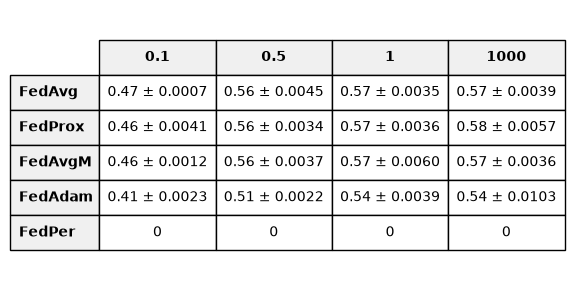

In [ ]:
import matplotlib.pyplot as plt
import numpy as np



# Helper to clean/format floats and handle NaNs cleanly
def clean_val(val):
  if isinstance(val, (float, np.floating)):
    return "-" if np.isnan(val) else f"{val:.4f}"
  return str(val)


col_labels = [0.1, 0.5, 1, 1000]
row_labels = ["FedAvg", "FedAvgM", "FedProx", "FedAdam", "FedPer"]

raw_data = [
  [f"{fedAvgMeans[k]:.2f} ± {fedAvgStds[k]:.4f}" for k in col_labels],
  [f"{fedAvgMMeans[k]:.2f} ± {fedAvgMStds[k]:.4f}" for k in col_labels],
  [f"{fedProxMeans[k]:.2f} ± {fedProxStds[k]:.4f}" for k in col_labels],
  [f"{fedAdamMeans[k]:.2f} ± {fedAdamStds[k]:.4f}" for k in col_labels],
  [0, 0, 0, 0]]

formatted_data = [[clean_val(v) for v in row] for row in raw_data]

# Create figure and axis with a cleaner aspect ratio
fig, ax = plt.subplots(figsize=(6, 3))
ax.axis("off")

# Use native row/col labels and styled styling
table = ax.table(
    cellText=formatted_data,
    rowLabels=row_labels,
    colLabels=col_labels,
    loc="center",
    cellLoc="center",
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.8)

# Optional: highlight header cells distinctively
for (row, col), cell in table.get_celld().items():
  if row == 0 or col == -1:
    cell.set_facecolor("#f0f0f0")
    cell.set_text_props(weight="bold")

plt.tight_layout()
plt.show()